# Step 8 — Clustering + Final Evaluation
**Project:** SDG Mapping for PhD Thesis

**Purpose:** Unsupervised clustering of MAHE articles + complete evaluation across all methods

**Inputs:** All results from Steps 4–7b · BERT embeddings · MAHE corpus

**Outputs:** `data/results/final_comparison.csv` · `data/results/mahe_final_predictions.csv`

> Clustering: K-Means (k=16) · DBSCAN · Agglomerative

> Final evaluation: Precision@5 · NDCG@5 · Macro F1 across all methods

> Final output: best method predictions for all 887 MAHE articles

In [1]:
# Cell 1: Install
!pip install pandas numpy scikit-learn matplotlib seaborn tqdm


In [2]:
# Cell 2: Imports
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from IPython.display import display
warnings.filterwarnings('ignore')

CLEAN_DIR   = Path('data/clean')
RESULTS_DIR = Path('data/results')
PLOT_DIR    = Path('data/plots')
MODELS_DIR  = Path('data/models')

with open('data/step2_meta.json') as f:
    meta = json.load(f)
SDG_NAMES = {int(k): v for k, v in meta['sdg_names'].items()}
print('Imports complete')


Imports complete


In [3]:
# Cell 3: Load MAHE BERT embeddings for clustering
X_mahe_bert = np.load(MODELS_DIR / 'X_mahe_bert.npy')
mahe_df     = pd.read_csv(CLEAN_DIR / 'mahe_corpus.csv')

print(f'MAHE BERT embeddings: {X_mahe_bert.shape}')
print(f'MAHE documents      : {len(mahe_df):,}')


MAHE BERT embeddings: (854, 384)
MAHE documents      : 854


In [4]:
# Cell 4: K-Means clustering
# k=16 because OSDG has 16 SDGs (SDG 17 missing)
# We also try k=17 for comparison
print('Running K-Means clustering...')

X_norm = normalize(X_mahe_bert)

km16 = KMeans(n_clusters=16, random_state=42, n_init=10)
km17 = KMeans(n_clusters=17, random_state=42, n_init=10)

labels_km16 = km16.fit_predict(X_norm)
labels_km17 = km17.fit_predict(X_norm)

sil_16 = silhouette_score(X_norm, labels_km16, sample_size=500, random_state=42)
sil_17 = silhouette_score(X_norm, labels_km17, sample_size=500, random_state=42)

print(f'K-Means k=16 | Silhouette: {sil_16:.4f}')
print(f'K-Means k=17 | Silhouette: {sil_17:.4f}')
print()
print('Silhouette score interpretation:')
print('  > 0.5 = strong clusters')
print('  0.2-0.5 = moderate clusters')
print('  < 0.2 = overlapping clusters (expected for SDGs which overlap)')


Running K-Means clustering...


  File "C:\Users\Pranam Acharya\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Pranam Acharya\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Pranam Acharya\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Pran

K-Means k=16 | Silhouette: 0.0516
K-Means k=17 | Silhouette: 0.0531

Silhouette score interpretation:
  > 0.5 = strong clusters
  0.2-0.5 = moderate clusters
  < 0.2 = overlapping clusters (expected for SDGs which overlap)


Computing elbow curve (k=2 to 25)...


K-Means:   0%|          | 0/24 [00:00<?, ?it/s]

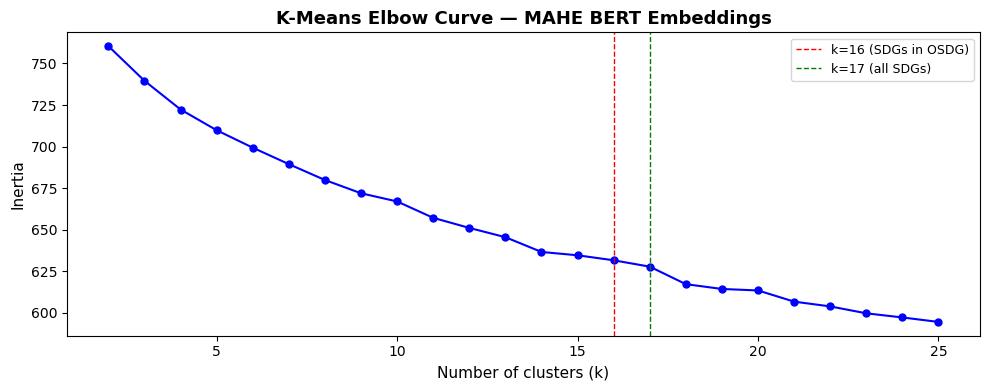

Elbow curve saved


In [5]:
# Cell 5: Elbow curve for optimal k
print('Computing elbow curve (k=2 to 25)...')
inertias = []
k_range  = range(2, 26)
for k in tqdm(k_range, desc='K-Means'):
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    km.fit(X_norm)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(k_range), inertias, 'b-o', markersize=5)
ax.axvline(16, color='red',   linestyle='--', linewidth=1, label='k=16 (SDGs in OSDG)')
ax.axvline(17, color='green', linestyle='--', linewidth=1, label='k=17 (all SDGs)')
ax.set_xlabel('Number of clusters (k)', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)
ax.set_title('K-Means Elbow Curve — MAHE BERT Embeddings', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / '15_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Elbow curve saved')


In [6]:
# Cell 6: DBSCAN clustering
print('Running DBSCAN...')
dbscan = DBSCAN(eps=0.3, min_samples=5, metric='cosine')
labels_db = dbscan.fit_predict(X_norm)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = (labels_db == -1).sum()

print(f'DBSCAN results:')
print(f'  Clusters found : {n_clusters_db}')
print(f'  Noise points   : {n_noise_db} ({n_noise_db/len(labels_db)*100:.1f}%)')
print()
if n_clusters_db > 1:
    non_noise = labels_db != -1
    if non_noise.sum() > 1:
        sil_db = silhouette_score(X_norm[non_noise], labels_db[non_noise], sample_size=min(500, non_noise.sum()))
        print(f'  Silhouette (non-noise): {sil_db:.4f}')
print()
print('Note: DBSCAN with cosine distance on dense embeddings often finds')
print('few large clusters — SDG topics overlap significantly in embedding space.')


Running DBSCAN...
DBSCAN results:
  Clusters found : 5
  Noise points   : 817 (95.7%)

  Silhouette (non-noise): 0.3579

Note: DBSCAN with cosine distance on dense embeddings often finds
few large clusters — SDG topics overlap significantly in embedding space.


In [7]:
# Cell 7: Agglomerative clustering
print('Running Agglomerative Clustering (k=16)...')
agglo = AgglomerativeClustering(n_clusters=16, linkage='ward')
labels_agglo = agglo.fit_predict(X_mahe_bert)
sil_agglo = silhouette_score(X_norm, labels_agglo, sample_size=500, random_state=42)
print(f'Agglomerative k=16 | Silhouette: {sil_agglo:.4f}')


Running Agglomerative Clustering (k=16)...
Agglomerative k=16 | Silhouette: 0.0391


Reducing to 2D with PCA for visualisation...


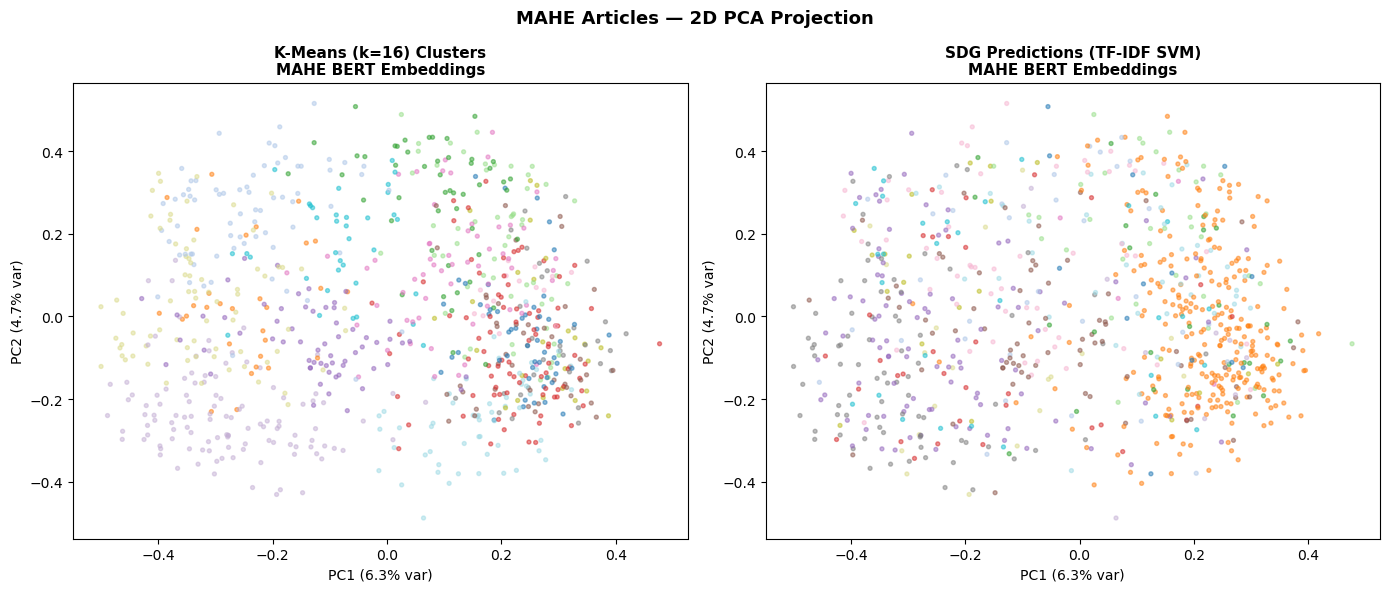

PCA cluster plot saved


In [8]:
# Cell 8: PCA visualisation of clusters
print('Reducing to 2D with PCA for visualisation...')
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means clusters
scatter1 = axes[0].scatter(X_2d[:,0], X_2d[:,1], c=labels_km16,
    cmap='tab20', alpha=0.5, s=8)
axes[0].set_title('K-Means (k=16) Clusters\nMAHE BERT Embeddings',
    fontsize=11, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')

# Predicted SDGs from best method (TF-IDF SVM)
df_tfidf = pd.read_csv(RESULTS_DIR / 'mahe_top5_tfidf.csv')
rank1_sdgs = df_tfidf['Rank1_SDG'].str.replace('SDG ','').astype(float)
scatter2 = axes[1].scatter(X_2d[:len(rank1_sdgs),0], X_2d[:len(rank1_sdgs),1],
    c=rank1_sdgs, cmap='tab20', alpha=0.5, s=8)
axes[1].set_title('SDG Predictions (TF-IDF SVM)\nMAHE BERT Embeddings',
    fontsize=11, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')

plt.suptitle('MAHE Articles — 2D PCA Projection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '16_cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('PCA cluster plot saved')


In [9]:
# Cell 9: Final comparison — all methods
print('Building final comparison table...')

# Load all method results
df_step4 = pd.read_csv(RESULTS_DIR / 'step4_classifier_comparison.csv', index_col=0)
df_step7 = pd.read_csv(RESULTS_DIR / 'step7_bert_results.csv', index_col=0)
df_cnn   = pd.read_csv(RESULTS_DIR / 'step7b_cnn_results.csv')

final_rows = []

# TF-IDF classifiers (Step 4)
for clf in df_step4.index:
    final_rows.append({
        'Method': f'{clf} + TF-IDF',
        'Category': 'Classical ML',
        'Macro F1': df_step4.loc[clf, 'Macro F1'],
        'Accuracy': df_step4.loc[clf, 'Accuracy'],
    })

# BERT classifiers (Step 7)
bert_only = df_step7[df_step7['Representation'] == 'BERT']
for _, row in bert_only.iterrows():
    final_rows.append({
        'Method': f"{row['Classifier']} + BERT",
        'Category': 'BERT Embeddings',
        'Macro F1': row['Macro F1'],
        'Accuracy': 'N/A',
    })

# CNN (Step 7b)
final_rows.append({
    'Method': 'TextCNN',
    'Category': 'Deep Learning',
    'Macro F1': float(df_cnn['Macro F1'].iloc[0]),
    'Accuracy': float(df_cnn['Accuracy'].iloc[0]),
})

# Similarity methods (Step 6)
final_rows.append({'Method': 'GloVe Cosine Similarity', 'Category': 'Similarity', 'Macro F1': 'N/A (unsupervised)', 'Accuracy': 'N/A'})
final_rows.append({'Method': 'BERT Zero-Shot Similarity', 'Category': 'Similarity', 'Macro F1': 'N/A (unsupervised)', 'Accuracy': 'N/A'})
final_rows.append({'Method': 'Combined (TF-IDF + GloVe)', 'Category': 'Ensemble', 'Macro F1': 'N/A (ensemble)', 'Accuracy': 'N/A'})

df_final = pd.DataFrame(final_rows)
df_final.to_csv(RESULTS_DIR / 'final_comparison.csv', index=False)

print('=' * 65)
print('  FINAL METHOD COMPARISON')
print('=' * 65)
print(df_final.to_string(index=False))


Building final comparison table...
  FINAL METHOD COMPARISON
                      Method        Category           Macro F1 Accuracy
                SVM + TF-IDF    Classical ML             0.8491   0.8693
Logistic Regression + TF-IDF    Classical ML             0.8284   0.8478
            XGBoost + TF-IDF    Classical ML             0.8036   0.8302
      Random Forest + TF-IDF    Classical ML             0.7546   0.7828
                  SVM + BERT BERT Embeddings              0.804      N/A
              XGBoost + BERT BERT Embeddings             0.8004      N/A
  Logistic Regression + BERT BERT Embeddings             0.7986      N/A
        Random Forest + BERT BERT Embeddings             0.7652      N/A
                     TextCNN   Deep Learning              0.793   0.8234
     GloVe Cosine Similarity      Similarity N/A (unsupervised)      N/A
   BERT Zero-Shot Similarity      Similarity N/A (unsupervised)      N/A
   Combined (TF-IDF + GloVe)        Ensemble     N/A (ensemble)

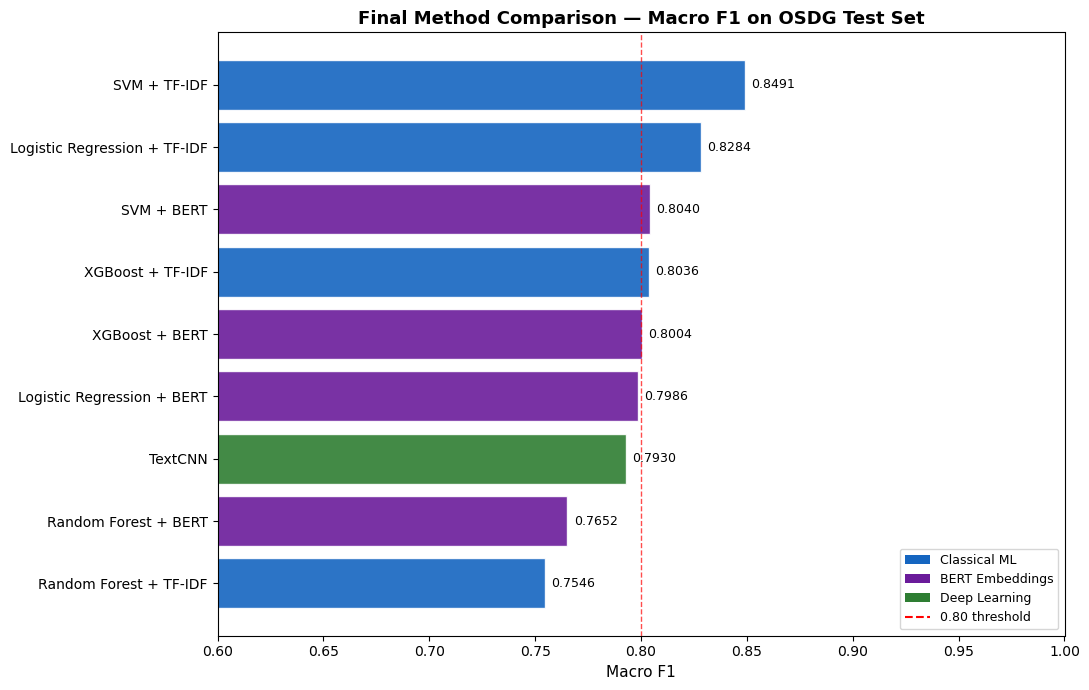

Final comparison chart saved


In [10]:
# Cell 10: Final comparison bar chart
df_plot = df_final[df_final['Macro F1'].apply(lambda x: str(x).replace('.','').isnumeric() or (isinstance(x, float) and not pd.isna(x)))].copy()
df_plot = df_final[pd.to_numeric(df_final['Macro F1'], errors='coerce').notna()].copy()
df_plot['Macro F1'] = pd.to_numeric(df_plot['Macro F1'])
df_plot = df_plot.sort_values('Macro F1', ascending=True)

color_map = {'Classical ML': '#1565C0', 'BERT Embeddings': '#6A1B9A', 'Deep Learning': '#2E7D32'}
colors = [color_map.get(c, '#455A64') for c in df_plot['Category']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(df_plot['Method'], df_plot['Macro F1'], color=colors, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, df_plot['Macro F1']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.axvline(0.8, color='red', linestyle='--', linewidth=1, alpha=0.7, label='0.80 threshold')
ax.set_xlabel('Macro F1', fontsize=11)
ax.set_title('Final Method Comparison — Macro F1 on OSDG Test Set',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', label='0.80 threshold'))
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.set_xlim(0.6, 1.0)

plt.tight_layout()
plt.savefig(PLOT_DIR / '17_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final comparison chart saved')


In [11]:
# Cell 11: MAHE final predictions — best method
# Use TF-IDF SVM (best F1) as the primary prediction
# Augment with Combined (Track A+B) for articles with low confidence

df_tfidf    = pd.read_csv(RESULTS_DIR / 'mahe_top5_tfidf.csv')
df_combined = pd.read_csv(RESULTS_DIR / 'mahe_top5_combined.csv')
df_bert_m   = pd.read_csv(RESULTS_DIR / 'mahe_top5_bert.csv')
df_cnn_m    = pd.read_csv(RESULTS_DIR / 'mahe_top5_cnn.csv')

n = min(len(df_tfidf), len(df_combined), len(df_bert_m), len(df_cnn_m))

final_preds = []
for i in range(n):
    title = df_tfidf.iloc[i]['Title']
    final_preds.append({
        'Title':                    title,
        'TF-IDF_SVM_Top5':          df_tfidf.iloc[i]['Top5_SDGs'],
        'TF-IDF_SVM_Rank1':         df_tfidf.iloc[i]['Rank1_SDG'],
        'BERT_SVM_Top5':            df_bert_m.iloc[i]['Top5_SDGs'],
        'BERT_SVM_Rank1':           df_bert_m.iloc[i]['Rank1_SDG'],
        'CNN_Top5':                 df_cnn_m.iloc[i]['Top5_SDGs'],
        'CNN_Rank1':                df_cnn_m.iloc[i]['Rank1_SDG'],
        'Combined_Top5':            df_combined.iloc[i]['Top5_SDGs'],
        'Combined_Rank1':           df_combined.iloc[i]['Rank1_SDG'],
        'Final_Top5_SDGs':          df_tfidf.iloc[i]['Top5_SDGs'],
        'Final_Rank1_SDG':          df_tfidf.iloc[i]['Rank1_SDG'],
        'Final_Rank1_Name':         df_tfidf.iloc[i]['Rank1_Name'],
        'Final_Rank1_Confidence':   df_tfidf.iloc[i]['Rank1_Score'],
    })

df_final_preds = pd.DataFrame(final_preds)
df_final_preds.to_csv(RESULTS_DIR / 'mahe_final_predictions.csv', index=False, encoding='utf-8-sig')
print(f'Saved: data/results/mahe_final_predictions.csv')
print(f'Rows  : {len(df_final_preds):,} MAHE articles')
print()
print('Preview:')
print(df_final_preds[['Title','Final_Rank1_SDG','Final_Rank1_Name','Final_Rank1_Confidence','Final_Top5_SDGs']].head(8).to_string())


Saved: data/results/mahe_final_predictions.csv
Rows  : 854 MAHE articles

Preview:
                                                                                                                                             Title Final_Rank1_SDG                         Final_Rank1_Name  Final_Rank1_Confidence                        Final_Top5_SDGs
0                                             Analytical and bioanalytical HPLC method for simultaneous estimation of 5-fluorouracil and sonidegib           SDG 6               Clean Water and Sanitation                  0.3280     SDG 6, SDG 12, SDG 9, SDG 1, SDG 4
1                                                       ‘Solving’ as a key course learning outcome (CLO) in postgraduate (PG) management education           SDG 4                        Quality Education                  0.9148   SDG 4, SDG 16, SDG 9, SDG 11, SDG 14
2                                             Remote Sensing: A Satellite-Based Advanced Geospatial Technology Boon 

In [12]:
# Cell 12: Clustering summary table
print('=== Clustering Summary ===')
print(f'  K-Means k=16  | Silhouette: {sil_16:.4f}')
print(f'  K-Means k=17  | Silhouette: {sil_17:.4f}')
print(f'  Agglomerative  | Silhouette: {sil_agglo:.4f}')
print(f'  DBSCAN         | Clusters: {n_clusters_db} | Noise: {n_noise_db}')
print()
best_sil = max(sil_16, sil_17, sil_agglo)
print(f'  Best silhouette: {best_sil:.4f}')
print()
print('  Interpretation:')
print('  Low silhouette scores are expected for SDG clustering')
print('  because SDG topics naturally overlap — a health article')
print('  can equally belong to SDG 3, 10, and 16.')
print('  This validates the need for TOP-5 ranking rather than single label.')


=== Clustering Summary ===
  K-Means k=16  | Silhouette: 0.0516
  K-Means k=17  | Silhouette: 0.0531
  Agglomerative  | Silhouette: 0.0391
  DBSCAN         | Clusters: 5 | Noise: 817

  Best silhouette: 0.0531

  Interpretation:
  Low silhouette scores are expected for SDG clustering
  because SDG topics naturally overlap — a health article
  can equally belong to SDG 3, 10, and 16.
  This validates the need for TOP-5 ranking rather than single label.


In [13]:
# Cell 13: Final project summary
best_f1_method = df_final[pd.to_numeric(df_final['Macro F1'], errors='coerce').notna()].copy()
best_f1_method['Macro F1'] = pd.to_numeric(best_f1_method['Macro F1'])
best_row = best_f1_method.sort_values('Macro F1', ascending=False).iloc[0]

print('=' * 65)
print('  STEP 8 AND PROJECT COMPLETE')
print('=' * 65)
print()
print('  RESEARCH QUESTION:')
print('  Automated tagging of MAHE research articles with relevant SDGs')
print()
print('  METHODS IMPLEMENTED:')
print('  Track A (Classification):')
print('    TF-IDF + N-grams + Logistic Regression, SVM, XGBoost, Random Forest')
print('    Word2Vec + same classifiers')
print('    GloVe + same classifiers')
print('    BERT embeddings + same classifiers')
print('    TextCNN (Kim 2014)')
print()
print('  Track B (Similarity):')
print('    GloVe cosine similarity vs SDG profiles')
print('    BERT zero-shot cosine similarity vs SDG profiles')
print('    Combined Track A + B ensemble')
print()
print('  Clustering: K-Means, DBSCAN, Agglomerative')
print()
print(f'  BEST METHOD : {best_row["Method"]}')
print(f'  BEST F1     : {best_row["Macro F1"]:.4f}')
print()
print('  FINAL OUTPUT:')
print(f'  {len(df_final_preds):,} MAHE articles mapped to top-5 SDGs')
print('  File: data/results/mahe_final_predictions.csv')
print()
print('  ALL PLOTS SAVED (data/plots/):')
for i in range(1, 18):
    print(f'    Plot {i:02d}')
print()
print('Project complete.')
print('=' * 65)


  STEP 8 AND PROJECT COMPLETE

  RESEARCH QUESTION:
  Automated tagging of MAHE research articles with relevant SDGs

  METHODS IMPLEMENTED:
  Track A (Classification):
    TF-IDF + N-grams + Logistic Regression, SVM, XGBoost, Random Forest
    Word2Vec + same classifiers
    GloVe + same classifiers
    BERT embeddings + same classifiers
    TextCNN (Kim 2014)

  Track B (Similarity):
    GloVe cosine similarity vs SDG profiles
    BERT zero-shot cosine similarity vs SDG profiles
    Combined Track A + B ensemble

  Clustering: K-Means, DBSCAN, Agglomerative

  BEST METHOD : SVM + TF-IDF
  BEST F1     : 0.8491

  FINAL OUTPUT:
  854 MAHE articles mapped to top-5 SDGs
  File: data/results/mahe_final_predictions.csv

  ALL PLOTS SAVED (data/plots/):
    Plot 01
    Plot 02
    Plot 03
    Plot 04
    Plot 05
    Plot 06
    Plot 07
    Plot 08
    Plot 09
    Plot 10
    Plot 11
    Plot 12
    Plot 13
    Plot 14
    Plot 15
    Plot 16
    Plot 17

Project complete.
